IMPORT LIBRARY & LOAD DATA

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Google Drive file ID
file_id = '1fLhcqpGYPZ64VhF8kxouNnF4bkPpcCWk'

# Construct the direct download link
download_url = f'https://drive.google.com/uc?export=download&id={file_id}'

# Load the data using the direct download link
df = pd.read_csv(download_url)

# Display the first few rows to confirm it loaded correctly
display(df.head())

,Product type,SKU,Price,Availability,Number of products sold,Revenue generated,Customer demographics,Stock levels,Lead times,Order quantities,...,Location,Lead time,Production volumes,Manufacturing lead time,Manufacturing costs,Inspection results,Defect rates,Transportation modes,Routes,Costs
0,haircare,SKU0,69.808006,55,802,8661.996792,Non-binary,58,7,96,...,Mumbai,29,215,29,46.279879,Pending,0.226410,Road,Route B,187.752075
1,skincare,SKU1,14.843523,95,736,7460.900065,Female,53,30,37,...,Mumbai,23,517,30,33.616769,Pending,4.854068,Road,Route B,503.065579
2,haircare,SKU2,11.319683,34,8,9577.749626,Unknown,1,10,88,...,Mumbai,12,971,27,30.688019,Pending,4.580593,Air,Route C,141.920282
3,skincare,SKU3,61.163343,68,83,7766.836426,Non-binary,23,13,59,...,Kolkata,24,937,18,35.624741,Fail,4.746649,Rail,Route A,254.776159
4,skincare,SKU4,4.805496,26,871,2686.505152,Non-binary,5,3,56,...,Delhi,5,414,3,92.065161,Fail,3.145580,Air,Route A,923.440632


DATA CLEANING

In [4]:
# Rename ambiguous columns
df = df.rename(columns={
    'Lead times': 'order_lead_time',
    'Lead time': 'supplier_lead_time',
    'Costs': 'total_cost'
})

# Check missing
df.isnull().sum()

,0
Product type,0
SKU,0
Price,0
Availability,0
Number of products sold,0
Revenue generated,0
Customer demographics,0
Stock levels,0
order_lead_time,0
Order quantities,0


In [5]:
# Display current column names to debug the KeyError
print(df.columns)

Index(['Product type', 'SKU', 'Price', 'Availability',
       'Number of products sold', 'Revenue generated', 'Customer demographics',
       'Stock levels', 'order_lead_time', 'Order quantities', 'Shipping times',
       'Shipping carriers', 'Shipping costs', 'Supplier name', 'Location',
       'supplier_lead_time', 'Production volumes', 'Manufacturing lead time',
       'Manufacturing costs', 'Inspection results', 'Defect rates',
       'Transportation modes', 'Routes', 'total_cost'],
      dtype='object')


In [6]:
# Standardize semua nama kolom
df.columns = df.columns.str.lower().str.replace(" ", "_")

# Cek hasil
print(df.columns)

Index(['product_type', 'sku', 'price', 'availability',
       'number_of_products_sold', 'revenue_generated', 'customer_demographics',
       'stock_levels', 'order_lead_time', 'order_quantities', 'shipping_times',
       'shipping_carriers', 'shipping_costs', 'supplier_name', 'location',
       'supplier_lead_time', 'production_volumes', 'manufacturing_lead_time',
       'manufacturing_costs', 'inspection_results', 'defect_rates',
       'transportation_modes', 'routes', 'total_cost'],
      dtype='object')


In [26]:
# Data type check
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype   
---  ------                   --------------  -----   
 0   product_type             100 non-null    object  
 1   sku                      100 non-null    object  
 2   price                    100 non-null    float64 
 3   availability             100 non-null    int64   
 4   number_of_products_sold  100 non-null    int64   
 5   revenue_generated        100 non-null    float64 
 6   customer_demographics    100 non-null    object  
 7   stock_levels             100 non-null    int64   
 8   order_lead_time          100 non-null    int64   
 9   order_quantities         100 non-null    int64   
 10  shipping_times           100 non-null    int64   
 11  shipping_carriers        100 non-null    object  
 12  shipping_costs           100 non-null    float64 
 13  supplier_name            100 non-null    object  
 14  location   

FEATURE ENGINEERING

In [9]:
# Total end-to-end lead time
df['total_lead_time'] = (
    df['order_lead_time'] +
    df['shipping_times'] +
    df['manufacturing_lead_time']
)

# Late delivery (dynamic threshold biar lebih realistis)
threshold = df['shipping_times'].median()
df['is_late'] = (df['shipping_times'] > threshold).astype(int)

# Inventory gap
df['stock_gap'] = df['stock_levels'] - df['number_of_products_sold']

# Efficiency metrics
df['revenue_per_unit'] = df['revenue_generated'] / df['number_of_products_sold']
df['cost_per_unit'] = df['total_cost'] / df['number_of_products_sold']

# Quick check
df[['total_lead_time','is_late','stock_gap']].head()

,total_lead_time,is_late,stock_gap
0,40,0,-744
1,62,0,-683
2,39,0,-7
3,37,0,-60
4,14,1,-866


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 29 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   product_type             100 non-null    object 
 1   sku                      100 non-null    object 
 2   price                    100 non-null    float64
 3   availability             100 non-null    int64  
 4   number_of_products_sold  100 non-null    int64  
 5   revenue_generated        100 non-null    float64
 6   customer_demographics    100 non-null    object 
 7   stock_levels             100 non-null    int64  
 8   order_lead_time          100 non-null    int64  
 9   order_quantities         100 non-null    int64  
 10  shipping_times           100 non-null    int64  
 11  shipping_carriers        100 non-null    object 
 12  shipping_costs           100 non-null    float64
 13  supplier_name            100 non-null    object 
 14  location                 10

KPI SUMMARY

In [12]:
kpi = {
    "Total Revenue": df['revenue_generated'].sum(),
    "Total Cost": df['total_cost'].sum(),
    "Avg Shipping Time": df['shipping_times'].mean(),
    "Late Rate (%)": df['is_late'].mean() * 100,
    "Avg Total Lead Time": df['total_lead_time'].mean()
}

for k, v in kpi.items():
    print(f"{k}: {round(v,2)}")

Total Revenue: 577604.82
Total Cost: 52924.58
Avg Shipping Time: 5.75
Late Rate (%): 47.0
Avg Total Lead Time: 36.48


SUPPLIER PERFORMANCE

In [13]:
supplier_perf = df.groupby('supplier_name').agg({
    'shipping_times':'mean',
    'is_late':'mean',
    'total_cost':'mean'
}).sort_values('is_late', ascending=False)

supplier_perf

,shipping_times,is_late,total_cost
supplier_name,,,
Supplier 1,6.074074,0.518519,574.851139
Supplier 5,6.222222,0.500000,536.022730
Supplier 4,5.555556,0.500000,521.810418
Supplier 2,5.500000,0.409091,515.027241
Supplier 3,5.200000,0.400000,468.800102


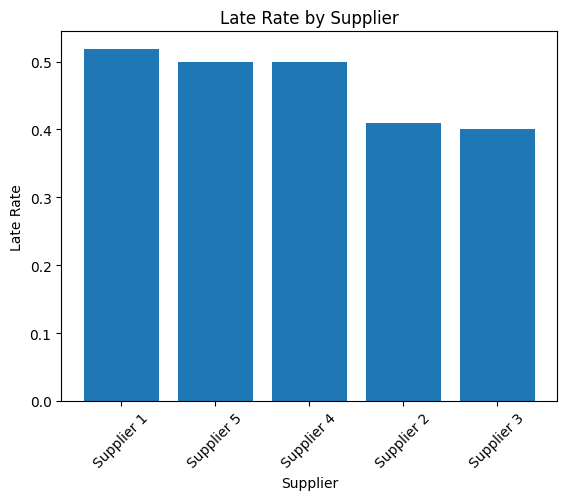

In [14]:
plt.figure()
plt.bar(supplier_perf.index, supplier_perf['is_late'])
plt.xticks(rotation=45)
plt.title("Late Rate by Supplier")
plt.xlabel("Supplier")
plt.ylabel("Late Rate")
plt.show()

TRANSPORTATION ANALYSIS

In [15]:
transport_perf = df.groupby('transportation_modes').agg({
    'shipping_times':'mean',
    'total_cost':'mean'
}).sort_values('shipping_times')

transport_perf

,shipping_times,total_cost
transportation_modes,,
Road,4.724138,553.385988
Air,5.115385,561.712596
Rail,6.571429,541.747556
Sea,7.117647,417.819148


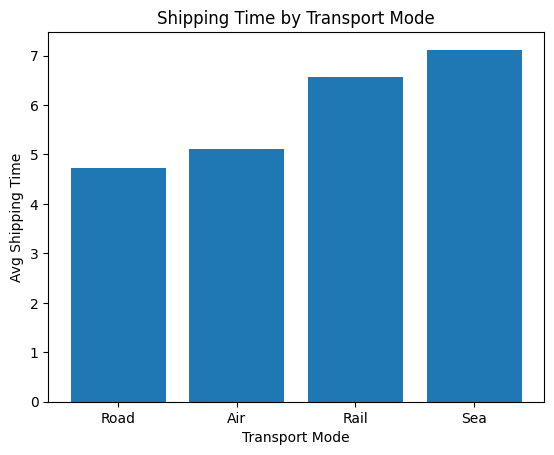

In [17]:
plt.figure()
plt.bar(transport_perf.index, transport_perf['shipping_times'])
plt.title("Shipping Time by Transport Mode")
plt.xlabel("Transport Mode")
plt.ylabel("Avg Shipping Time")
plt.show()

INVENTORY RISK ANALYSIS

In [18]:
inventory_risk = df.sort_values('stock_gap')

inventory_risk[['sku','stock_gap']].head(10)

,sku,stock_gap
9,SKU9,-966
10,SKU10,-945
36,SKU36,-945
78,SKU78,-941
37,SKU37,-938
11,SKU11,-914
94,SKU94,-910
44,SKU44,-906
47,SKU47,-906
58,SKU58,-886


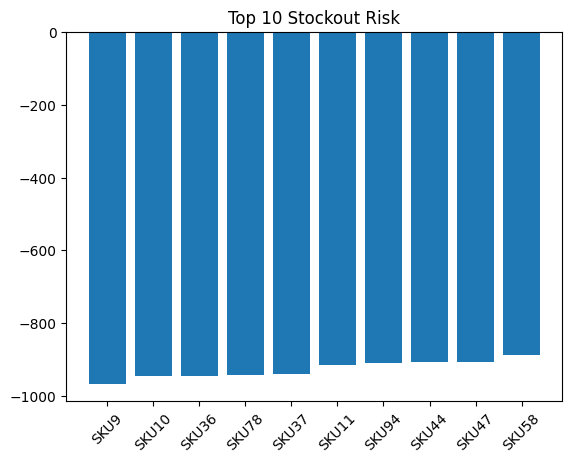

In [19]:
top_risk = df.nsmallest(10, 'stock_gap')

plt.figure()
plt.bar(top_risk['sku'], top_risk['stock_gap'])
plt.xticks(rotation=45)
plt.title("Top 10 Stockout Risk")
plt.show()

COST vs PERFORMANCE

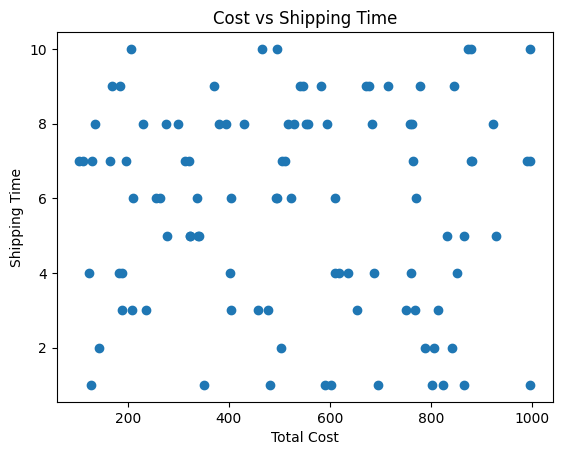

In [20]:
plt.figure()
plt.scatter(df['total_cost'], df['shipping_times'])
plt.title("Cost vs Shipping Time")
plt.xlabel("Total Cost")
plt.ylabel("Shipping Time")
plt.show()

LEAD TIME DISTRIBUTION

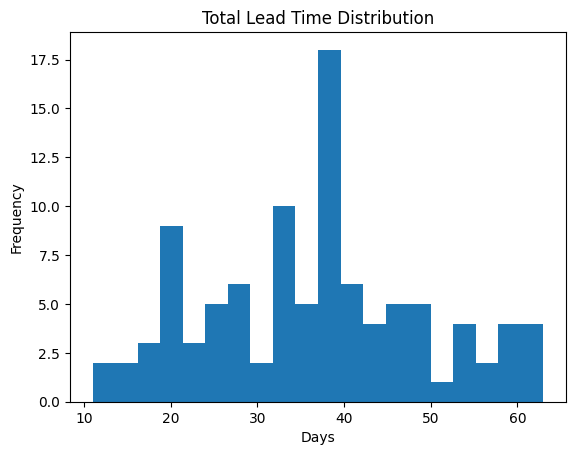

In [21]:
plt.figure()
plt.hist(df['total_lead_time'], bins=20)
plt.title("Total Lead Time Distribution")
plt.xlabel("Days")
plt.ylabel("Frequency")
plt.show()

QUALITY & DEFECT ANALYSIS

In [22]:
quality = df.groupby('inspection_results').agg({
    'defect_rates':'mean',
    'total_cost':'mean'
})

quality

,defect_rates,total_cost
inspection_results,,
Fail,2.569302,511.389683
Pass,2.039043,572.836117
Pending,2.154218,520.471193


CORRELATION ANALYSIS

In [23]:
corr = df[['shipping_times','total_cost','defect_rates','total_lead_time']].corr()

corr

,shipping_times,total_cost,defect_rates,total_lead_time
shipping_times,1.000000,-0.045541,-0.036673,0.171218
total_cost,-0.045541,1.000000,0.032072,0.106719
defect_rates,-0.036673,0.032072,1.000000,0.100799
total_lead_time,0.171218,0.106719,0.100799,1.000000


SEGMENTATION

In [24]:
df['demand_segment'] = pd.qcut(
    df['number_of_products_sold'],
    3,
    labels=['Low','Medium','High']
)

df[['number_of_products_sold','demand_segment']].head()

,number_of_products_sold,demand_segment
0,802,High
1,736,High
2,8,Low
3,83,Low
4,871,High
